# Non-linear Regression

In [3]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt

url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML0101EN-SkillsNetwork/labs/Module%202/data/china_gdp.csv"
df = pd.read_csv(url)  # directly read into a DataFrame
df.head()

df.head()

,Year,Value
0,1960,5.918412e+10
1,1961,4.955705e+10
2,1962,4.668518e+10
3,1963,5.009730e+10
4,1964,5.906225e+10


Plotting the dataset

Text(0, 0.5, 'Year')

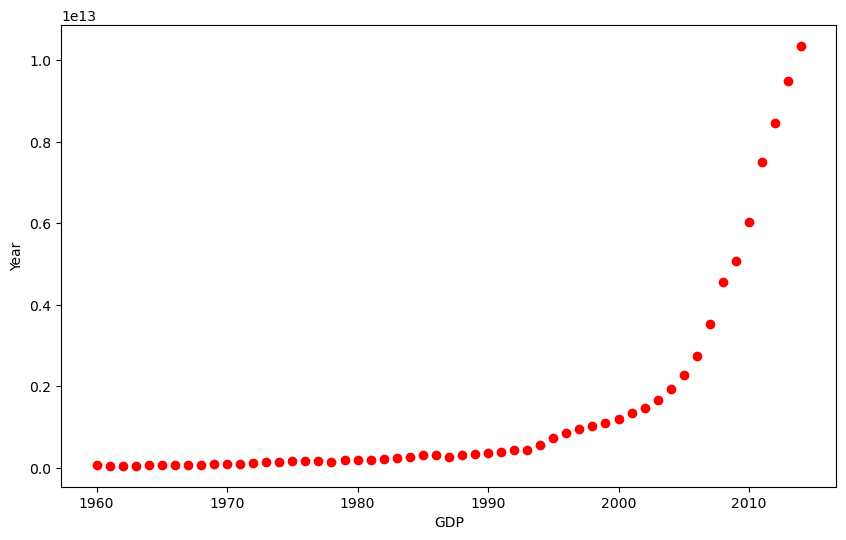

In [4]:
plt.figure(figsize=(10,6))
x_data, y_data = (df['Year'].values, df["Value"].values)
plt.plot(x_data, y_data, 'ro')
plt.xlabel("GDP")
plt.ylabel("Year")  

Logistic Model

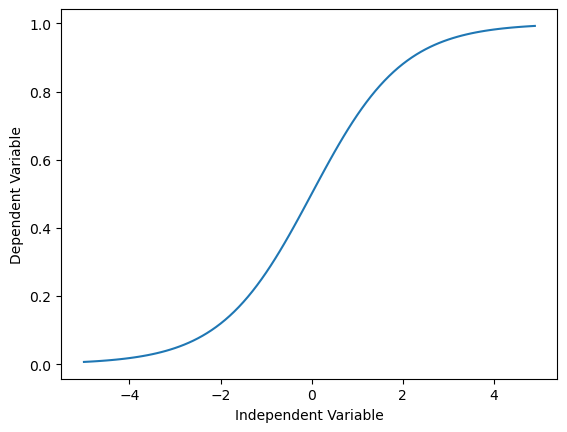

In [5]:
X = np.arange(-5.0, 5.0, 0.1)
Y = 1.0/(1.0 + np.exp(-X))

plt.plot(X, Y)
plt.ylabel('Dependent Variable')
plt.xlabel('Independent Variable')
plt.show()

Building the model

In [6]:
def sigmoid(x, Beta_1, Beta_2):
    y = 1/(1+np.exp(-Beta_1*(x-Beta_2)))
    return y

looking at a sample sigmoid line that might fit the data

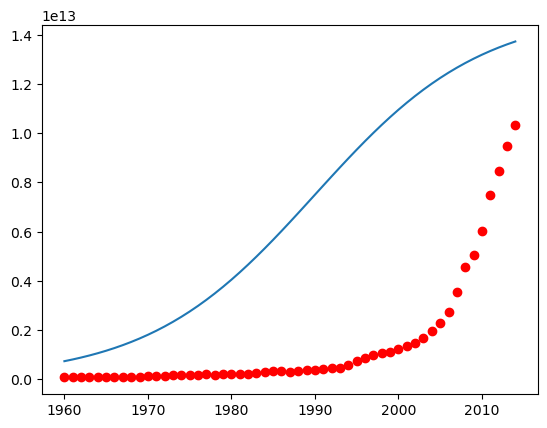

In [7]:
beta_1 = 0.10
beta_2 = 1990.0

Y_pred = sigmoid(x_data, beta_1, beta_2)

plt.plot(x_data, Y_pred*15000000000000)
plt.plot(x_data,y_data, 'ro')
plt.show()

now all we got to do is find the best parameters so that the line can fit the observation well

In [ ]:
# let us normalize our data 
xdata =x_data/max(x_data)
ydata =y_data/max(y_data)

we can fit our line using curve_fit, which is a library used to fit user defined functions to data,

It uses non-linear least squares. It optimizes the values of the parameters so that the sum of the square residuals(errors) is least (is minimized)

In [9]:
from scipy.optimize import curve_fit

popt, pcov = curve_fit(sigmoid, xdata, ydata)
print(" beta_1 = %f, beta_2 = %f" % (popt[0], popt[1]))

 beta_1 = 690.451711, beta_2 = 0.997207


Now we plot our resulting regression model.


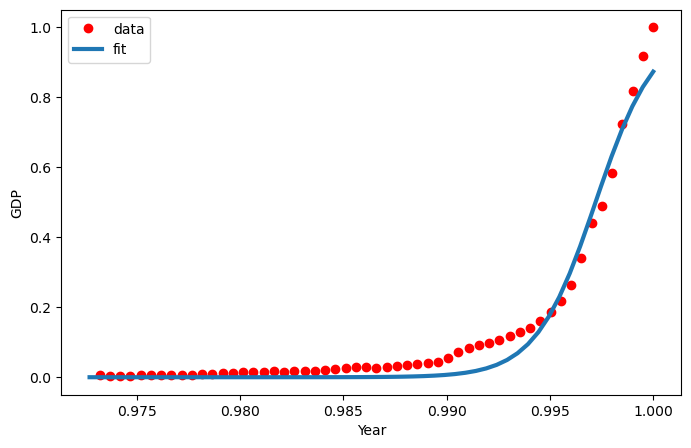

In [10]:
x = np.linspace(1960,2015,55)
x = x/max(x)
plt.figure(figsize=(8,5))
y = sigmoid(x, *popt)
plt.plot(xdata, ydata, 'ro', label='data')
plt.plot(x, y, linewidth=3.0, label='fit')
plt.legend(loc='best')
plt.ylabel('GDP')
plt.xlabel('Year')
plt.show()

Evaluation

In [11]:
# split the data into train and test
msk = np.random.rand(len(df)) < 0.8
train_x = xdata[msk]
train_y = ydata[msk]
test_x = xdata[~msk]
test_y = ydata[~msk]


#now we build the model using the train set
popt, pcov = curve_fit(sigmoid, train_x, train_y)

#predict using test set
y_hat = sigmoid(test_x, *popt)

print("Mean absolute error: %.2f" % np.mean(np.absolute(y_hat - test_y)))
print("Residual sum of squares (MSE): %.2f" % np.mean((y_hat - test_y) ** 2))
from sklearn.metrics import r2_score
print("R2-score: %.2f" % r2_score(test_y,y_hat) )

Mean absolute error: 0.02
Residual sum of squares (MSE): 0.00
R2-score: 0.43


The model predicts the shape of GDP growth well (small MAE and MSE).

It doesn’t capture all variations in the data relative to its mean → hence moderate R²